# Notebook final — Mineração de Dados · CRISP-DM

Pipeline de ponta a ponta sobre o conjunto de dados **Drug Adverse Events** (OpenFDA /
FAERS): preparação, transformação, balanceamento e modelagem. O objetivo é prever se um
evento adverso é grave (`serious`).

O fluxo tem duas características centrais:

1. **Execução preguiçosa (*lazy*).** A engenharia de dados usa **Polars LazyFrame** —
   limpeza, faixa etária e *feature engineering* compõem uma única *query*, materializada
   de uma vez (em *streaming*), sem DataFrames intermediários. A modelagem usa um
   **pipeline sklearn/imblearn** que só executa no `.fit()`. Assim, nenhuma etapa precisa
   terminar e materializar todo o resultado antes da seguinte.
2. **Balanceamento da classe `serious` por SMOTE.** O alvo é desbalanceado (classes 1 e
   2). Em vez de `class_weight`, aplica-se **SMOTE** (oversampling sintético baseado em
   KNN) *dentro* do pipeline: equilibra automaticamente qualquer proporção
   (*dataset-agnóstico*) e atua apenas nos *folds* de treino (sem vazamento).

## 0. Configuração e *imports*

In [1]:
import warnings
warnings.filterwarnings("ignore")

import collections
import json
import math
import os
import time
from pathlib import Path

import ijson
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import pyarrow.parquet as pq

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score,
    confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV, StratifiedKFold, train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Semente única para todas as etapas estocásticas (reprodutibilidade).
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 120)

# MODO_RAPIDO reduz n_iter/cv das buscas para uma execução de demonstração rápida.
# Vem do ambiente (padrão True): defina MODO_RAPIDO=false para o run completo
# (grades de hiperparâmetros completas + cv=5).
MODO_RAPIDO = os.environ.get("MODO_RAPIDO", "true").strip().lower() in ("1", "true", "yes")
print("MODO_RAPIDO =", MODO_RAPIDO, "| polars", pl.__version__, "| pandas", pd.__version__)

MODO_RAPIDO = False | polars 1.42.0 | pandas 3.0.2


In [2]:
# Resolução de caminhos robusta: o notebook roda de notebooks/ ou da raiz do projeto.
_cwd = Path.cwd()
PROJ = _cwd.parent if _cwd.name == "notebooks" else _cwd
DATASETS_DIR = PROJ / "datasets"
VALID_DIR = PROJ / "validation"
OUTPUTS_DIR = PROJ / "outputs"
MODELS_DIR = OUTPUTS_DIR / "models"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Reaproveitamento: experimentos com modelo já treinado em outputs/models/ pulam a busca
# de hiperparâmetros (REUSE_TRAINED vem do ambiente, padrão True). Útil para acrescentar
# um modelo novo (ex.: Regressão Logística) sem refazer as buscas caras das árvores.
REUSE_TRAINED = os.environ.get("REUSE_TRAINED", "true").strip().lower() in ("1", "true", "yes")
# Log de progresso tailável ao vivo (o nbclient só descarrega a saída das células no fim).
PROGRESS_LOG = OUTPUTS_DIR / "_progress.log"
PROGRESS_LOG.write_text("", encoding="utf-8")

print("DATASETS_DIR :", DATASETS_DIR, "|", len(list(DATASETS_DIR.glob("*.json"))), "JSON")
print("VALID_DIR    :", VALID_DIR, "|", len(list(VALID_DIR.glob("*.json"))), "JSON")
print("OUTPUTS_DIR  :", OUTPUTS_DIR, "| REUSE_TRAINED =", REUSE_TRAINED)

DATASETS_DIR : /home/ubuntu/datamining-project-unifei/datasets | 3 JSON
VALID_DIR    : /home/ubuntu/datamining-project-unifei/validation | 2 JSON
OUTPUTS_DIR  : /home/ubuntu/datamining-project-unifei/outputs | REUSE_TRAINED = True


## 1. Entendimento dos dados

Os dados vêm do **OpenFDA** (FDA Adverse Event Reporting System — FAERS): relatórios de
reações adversas e erros de medicação. Cada registro é um relatório com dados do
paciente e uma lista aninhada de medicamentos (`patient.drug[]`).

**Alvo (`serious`):** `1` = grave, `2` = não-grave — classes desbalanceadas (~62%/38%).

**Atributos usados:** país, sexo, faixa etária (derivada), e atributos de medicamentos
(substâncias ativas, produtos, contagens) — mais 5 *features* de engenharia.

## 2. Ingestão preguiçosa (*streaming*)

Os JSON são lidos **registro a registro** com `ijson` (memória O(1) por registro) e
gravados em **Parquet** em lotes. A lista de medicamentos de cada relatório é agregada
*no próprio registro* — não há *groupby* global, então o pico de memória independe do
tamanho do dataset. A mesma função serve para treino (`datasets/`) e validação
(`validation/`).

In [3]:
def normalize_text_value(value):
    """Normaliza texto para MAIÚSCULAS sem espaços nas bordas.

    Retorna None para valores vazios/ausentes, de modo que a agregação os ignore.
    """
    if value is None:
        return None
    value = str(value).strip()
    return value.upper() if value else None


def join_unique_values(values):
    """Resume várias entradas (ex.: vários medicamentos) em texto único e ordenado.

    Une os valores distintos com ' | '. Devolve 'unknown' quando não há nenhum valor —
    convenção esperada pelas etapas seguintes (contagem por '|' e flags).
    """
    vals = [str(v).strip() for v in values if v is not None and str(v).strip()]
    uniq = sorted(set(vals))
    return " | ".join(uniq) if uniq else "unknown"


def _to_float(value):
    """Converte para float; devolve None quando não numérico (mantém schema estável)."""
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


def _flatten_report(rec):
    """Achata um relatório OpenFDA em uma linha, agregando sua lista patient.drug[].

    A agregação é feita por registro porque cada relatório já carrega seus próprios
    medicamentos — abordagem naturalmente *streaming* e de baixa memória.
    """
    patient = rec.get("patient") or {}
    drugs = patient.get("drug") or []
    if isinstance(drugs, dict):  # um único medicamento pode vir como objeto, não lista
        drugs = [drugs]
    active = join_unique_values(
        normalize_text_value((d.get("activesubstance") or {}).get("activesubstancename"))
        for d in drugs
    )
    medic = join_unique_values(
        normalize_text_value(d.get("medicinalproduct")) for d in drugs
    )
    drugchar = join_unique_values(
        None if d.get("drugcharacterization") is None
        else str(d.get("drugcharacterization")).strip()
        for d in drugs
    )
    sid = rec.get("safetyreportid")
    return {
        "safetyreportid": str(sid) if sid is not None else None,
        "serious": None if rec.get("serious") is None else str(rec.get("serious")),
        "occurcountry": rec.get("occurcountry"),
        "patient.patientsex": None if patient.get("patientsex") is None
        else str(patient.get("patientsex")),
        "patient.patientonsetage": _to_float(patient.get("patientonsetage")),
        "patient.patientonsetageunit": None if patient.get("patientonsetageunit") is None
        else str(patient.get("patientonsetageunit")),
        "patient.drug.activesubstance.activesubstancename": active,
        "patient.drug.drugcharacterization": drugchar,
        "patient.drug.medicinalproduct": medic,
        "patient.drug.count": len(drugs),
    }


# Schema fixo: garante tipos estáveis entre lotes e arquivos (treino e validação).
_RAW_SCHEMA = {
    "safetyreportid": pl.Utf8,
    "serious": pl.Utf8,
    "occurcountry": pl.Utf8,
    "patient.patientsex": pl.Utf8,
    "patient.patientonsetage": pl.Float64,
    "patient.patientonsetageunit": pl.Utf8,
    "patient.drug.activesubstance.activesubstancename": pl.Utf8,
    "patient.drug.drugcharacterization": pl.Utf8,
    "patient.drug.medicinalproduct": pl.Utf8,
    "patient.drug.count": pl.Int64,
}


def ingest_to_parquet(json_paths, dest_parquet, batch_size=20_000):
    """Lê os JSON em *streaming* e grava as linhas achatadas em Parquet, em lotes.

    Escrever em lotes mantém a memória limitada para datasets grandes. Retorna o total
    de registros gravados. O Parquet resultante é a entrada da query preguiçosa.
    """
    dest_parquet = Path(dest_parquet)
    writer = None
    batch, total = [], 0

    def _flush(rows):
        nonlocal writer, total
        if not rows:
            return
        table = pl.DataFrame(rows, schema=_RAW_SCHEMA).to_arrow()
        if writer is None:
            writer = pq.ParquetWriter(dest_parquet, table.schema)
        writer.write_table(table)
        total += len(rows)

    try:
        for path in json_paths:
            with open(path, "rb") as fh:
                for rec in ijson.items(fh, "results.item"):
                    batch.append(_flatten_report(rec))
                    if len(batch) >= batch_size:
                        _flush(batch)
                        batch = []
        _flush(batch)
    finally:
        if writer is not None:
            writer.close()
    return total

## 3. Transformação preguiçosa (Polars LazyFrame)

Limpeza, faixa etária e *feature engineering* são expressas como **uma única *query*
preguiçosa** sobre o Parquet. Nada é calculado até `collect()`, que roda em *streaming*.

Os atributos numéricos saem **sem padronização**: ela é aplicada dentro do pipeline de
modelagem (ajustada por *fold*), o que evita padronizar duas vezes e mantém todos os
parâmetros de transformação encapsulados no próprio modelo.

In [4]:
# Códigos de unidade de idade do OpenFDA -> fator de conversão para anos.
AGE_UNIT_TO_YEARS = {
    "800": 10.0,        # década
    "801": 1.0,         # ano
    "802": 1 / 12,      # mês
    "803": 1 / 52,      # semana
    "804": 1 / 365,     # dia
    "805": 1 / (365 * 24),  # hora
}


def _count_pipe(column):
    """Conta itens separados por '|' numa coluna de texto.

    Devolve 0 quando o valor é 'unknown' (convenção de join_unique_values).
    """
    col = pl.col(column)
    nonempty = col.str.split("|").list.eval(
        pl.element().str.strip_chars().str.len_chars() > 0
    ).list.sum()
    return (
        pl.when(col.str.to_lowercase() == "unknown").then(0).otherwise(nonempty)
    ).cast(pl.Int64)


def build_feature_frame(parquet_path):
    """Query preguiçosa de limpeza + faixa etária + *feature engineering*.

    Toda a transformação é lazy e só materializa no collect() do chamador, evitando
    DataFrames intermediários. A faixa etária ainda pode conter 'unknown' aqui — esses
    casos são preenchidos depois pelo imputador KNN (Seção 4). Retorna um LazyFrame.
    """
    sex_map = {"1": "male", "2": "female", "0": "unknown"}

    # Idade em anos; valores fora de [0, 120] são descartados (provável erro de registro).
    age_years = (
        pl.col("patient.patientonsetage")
        * pl.col("patient.patientonsetageunit").replace_strict(
            AGE_UNIT_TO_YEARS, default=None
        )
    )
    age_years = (
        pl.when((age_years >= 0) & (age_years <= 120)).then(age_years).otherwise(None)
    )

    return (
        pl.scan_parquet(parquet_path)
        .filter(pl.col("occurcountry").is_not_null())  # relatório sem país é descartado
        .with_columns(
            pl.col("patient.patientsex")
            .replace_strict(sex_map, default="unknown")
            .alias("patient.patientsex"),
            age_years.alias("_age_years"),
        )
        .with_columns(
            # Binning da idade; 'unknown' marca o que será imputado por KNN na Seção 4.
            pl.when(pl.col("_age_years").is_null()).then(pl.lit("unknown"))
            .when(pl.col("_age_years") < 2).then(pl.lit("baby_early_childhood"))
            .when(pl.col("_age_years") < 12).then(pl.lit("child"))
            .when(pl.col("_age_years") < 18).then(pl.lit("adolescent"))
            .when(pl.col("_age_years") < 30).then(pl.lit("young_adult"))
            .when(pl.col("_age_years") < 60).then(pl.lit("adult"))
            .otherwise(pl.lit("elderly"))
            .alias("patient.ageGroupCalculated")
        )
        .with_columns(
            (pl.col("patient.ageGroupCalculated") == "unknown")
            .cast(pl.Int64)
            .alias("patient.ageGroupCalculated_was_imputed"),
            _count_pipe("patient.drug.activesubstance.activesubstancename")
            .alias("feature_n_active_substances"),
            _count_pipe("patient.drug.drugcharacterization").alias("feature_n_drug_types"),
            (pl.col("patient.drug.medicinalproduct").str.to_lowercase() != "unknown")
            .cast(pl.Int64)
            .alias("feature_has_medicinal_product"),
            (pl.col("patient.drug.count") > 1).cast(pl.Int64).alias("feature_multiple_drugs"),
            (pl.col("occurcountry").str.to_uppercase() == "US")
            .cast(pl.Int64)
            .alias("feature_is_usa"),
            pl.col("serious").cast(pl.Int64, strict=False).alias("serious"),
        )
        .filter(pl.col("serious").is_not_null())  # sem rótulo não há treino nem avaliação
        .drop("_age_years", "patient.patientonsetage", "patient.patientonsetageunit")
    )


def materialize(parquet_path):
    """Materializa a query preguiçosa em DataFrame pandas (fronteira Polars -> sklearn).

    engine='streaming' processa em blocos: o pico de memória não cresce com o tamanho
    do dataset. A conversão para pandas é necessária pois o restante usa sklearn.
    """
    return build_feature_frame(parquet_path).collect(engine="streaming").to_pandas()

In [5]:
# Ingestão + transformação preguiçosa do conjunto de TREINO (datasets/).
RAW_TRAIN_PARQUET = OUTPUTS_DIR / "_raw_reports_train.parquet"
n_raw = ingest_to_parquet(sorted(DATASETS_DIR.glob("*.json")), RAW_TRAIN_PARQUET)
prepared = materialize(RAW_TRAIN_PARQUET)

print(f"Registros brutos lidos : {n_raw}")
print(f"Após limpeza (lazy)    : {prepared.shape}")
print("Distribuição de 'serious':")
print(prepared["serious"].value_counts(normalize=True).sort_index().round(4))
prepared.head(3)

Registros brutos lidos : 36000
Após limpeza (lazy)    : (32309, 15)
Distribuição de 'serious':
serious
1    0.623
2    0.377
Name: proportion, dtype: float64


,safetyreportid,serious,occurcountry,patient.patientsex,patient.drug.activesubstance.activesubstancename,patient.drug.drugcharacterization,patient.drug.medicinalproduct,patient.drug.count,patient.ageGroupCalculated,patient.ageGroupCalculated_was_imputed,feature_n_active_substances,feature_n_drug_types,feature_has_medicinal_product,feature_multiple_drugs,feature_is_usa
0,24916426,1,NZ,female,ESTRADIOL,1,ESTRADIOL,1,adult,0,1,1,1,0,0
1,24917560,1,CA,unknown,CARBAMAZEPINE | CENOBAMATE | LAMOTRIGINE | OXC...,1 | 2,CARBAMAZEPINE | LAMOTRIGINE | OXCARBAZEPINE | ...,12,unknown,1,4,2,1,1,0
2,24917803,2,US,male,DUPILUMAB,1,DUPIXENT,2,elderly,0,1,1,1,1,1


## 4. Imputação KNN da faixa etária (ajustada só no treino)

A faixa etária faltante (`unknown`) é preenchida por um **classificador KNN** que
aprende a faixa a partir de país, sexo, medicamentos e contagem. É **supervisionado** e
precisa ser ajustado **somente no treino** (registros com faixa conhecida), para não
vazar informação para teste/validação.

> Atenção: esta é a **única** materialização *eager* no meio do fluxo — KNN supervisionado
> não cabe na *query* preguiçosa. **Não confundir** com o SMOTE da Seção 7, que balanceia
> o alvo `serious`.

O `train_test_split` estratificado em `serious` vem antes da imputação, exatamente para
garantir que o KNN só veja dados de treino.

In [6]:
TARGET = "serious"
# Atributos preditores do imputador KNN da faixa etária.
KNN_FEATURES = [
    "occurcountry", "patient.patientsex", "patient.drug.drugcharacterization",
    "patient.drug.activesubstance.activesubstancename",
    "patient.drug.medicinalproduct", "patient.drug.count",
]


def build_age_group_imputer():
    """Cria o imputador KNN da faixa etária (ColumnTransformer + KNeighborsClassifier).

    Categóricas via One-Hot, textos de medicamentos via CountVectorizer e a contagem
    padronizada. KNN com k=5 ponderado por distância.
    """
    preprocessor = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"),
         ["occurcountry", "patient.patientsex", "patient.drug.drugcharacterization"]),
        ("active_substance",
         CountVectorizer(max_features=100, token_pattern=r"(?u)\b[\w-]+\b"),
         "patient.drug.activesubstance.activesubstancename"),
        ("medicinal_product",
         CountVectorizer(max_features=100, token_pattern=r"(?u)\b[\w-]+\b"),
         "patient.drug.medicinalproduct"),
        ("num", StandardScaler(), ["patient.drug.count"]),
    ])
    return Pipeline([
        ("preprocessor", preprocessor),
        ("knn", KNeighborsClassifier(n_neighbors=5, weights="distance",
                                     algorithm="brute", metric="euclidean")),
    ])


def impute_age_groups(df, fitted_imputer):
    """Preenche as faixas 'unknown' de df com o imputador já ajustado (sem refit).

    Aplicável a treino, teste e validação — sempre com o MESMO imputador treinado, o que
    preserva a ausência de vazamento. Retorna uma cópia transformada.
    """
    df = df.copy()
    unknown = df["patient.ageGroupCalculated"] == "unknown"
    if unknown.any():
        df.loc[unknown, "patient.ageGroupCalculated"] = fitted_imputer.predict(
            df.loc[unknown, KNN_FEATURES]
        )
    return df

In [7]:
# Split estratificado 70/30 ANTES da imputação (o KNN só pode ver o treino).
train_df, test_df = train_test_split(
    prepared, test_size=0.30, random_state=RANDOM_STATE, stratify=prepared[TARGET],
)

# Ajusta o imputador apenas nos registros de treino com faixa conhecida.
age_imputer = build_age_group_imputer()
known = train_df["patient.ageGroupCalculated"] != "unknown"
age_imputer.fit(
    train_df.loc[known, KNN_FEATURES],
    train_df.loc[known, "patient.ageGroupCalculated"],
)

n_train_unk = int((train_df["patient.ageGroupCalculated"] == "unknown").sum())
n_test_unk = int((test_df["patient.ageGroupCalculated"] == "unknown").sum())
train_df = impute_age_groups(train_df, age_imputer)
test_df = impute_age_groups(test_df, age_imputer)

print(f"KNN ajustado em {int(known.sum())} registros conhecidos do treino.")
print(f"Faixas imputadas -> treino: {n_train_unk} | teste: {n_test_unk}")
print("Treino:", train_df.shape, "| Teste:", test_df.shape)

KNN ajustado em 13671 registros conhecidos do treino.
Faixas imputadas -> treino: 8945 | teste: 3781
Treino: (22616, 15) | Teste: (9693, 15)


## 5. Conjuntos de *features* (Atributos)

Para medir o impacto da engenharia de atributos, comparamos dois conjuntos:

- **A — Baseline (≈11 após One-Hot):** atributos originais antes da engenharia.
- **B — Completo (17):** Baseline + 5 *features* de engenharia + a *flag* da imputação KNN.

Os textos de medicamentos são vetorizados por **TF-IDF** dentro do pipeline (ajustado
por *fold*, sem vazamento).

In [8]:
COL_NUMERICAS = ["patient.drug.count",
                 "feature_n_active_substances", "feature_n_drug_types"]
COL_CATEGORICAS = ["occurcountry", "patient.patientsex", "patient.ageGroupCalculated"]
COL_BINARIAS = ["patient.ageGroupCalculated_was_imputed",
                "feature_has_medicinal_product", "feature_multiple_drugs",
                "feature_is_usa"]
COL_TEXTO = ["patient.drug.activesubstance.activesubstancename",
             "patient.drug.medicinalproduct"]

FEATURES_ENGENHARIA = ["feature_n_active_substances", "feature_n_drug_types",
                       "feature_has_medicinal_product", "feature_multiple_drugs",
                       "feature_is_usa"]
FLAG_IMPUTACAO = "patient.ageGroupCalculated_was_imputed"

CONJUNTO_A = ["occurcountry", "patient.patientsex", "patient.ageGroupCalculated",
              "patient.drug.count",
              "patient.drug.activesubstance.activesubstancename",
              "patient.drug.medicinalproduct"]
CONJUNTO_B = CONJUNTO_A + FEATURES_ENGENHARIA + [FLAG_IMPUTACAO]

feature_sets = {
    "A_baseline": {"rotulo": "Baseline (11)",
                   "colunas": [c for c in CONJUNTO_A if c in train_df.columns]},
    "B_completo": {"rotulo": "Completo (17)",
                   "colunas": [c for c in CONJUNTO_B if c in train_df.columns]},
}

X_train, y_train = train_df.drop(columns=[TARGET]), train_df[TARGET].astype(int)
X_test, y_test = test_df.drop(columns=[TARGET]), test_df[TARGET].astype(int)
pd.DataFrame([{"conjunto": k, **{"rotulo": v["rotulo"],
              "n_colunas": len(v["colunas"])}} for k, v in feature_sets.items()])

,conjunto,rotulo,n_colunas
0,A_baseline,Baseline (11),6
1,B_completo,Completo (17),12


## 6. Pré-processador (sem vazamento)

Cada tipo de coluna recebe um tratamento, todo ajustado **dentro da validação cruzada**:

- **Numéricas:** imputação por mediana + padronização (`StandardScaler`).
- **Categóricas:** moda + `OneHotEncoder` (categorias raras agrupadas).
- **Binárias:** `passthrough`.
- **Texto:** `TfidfVectorizer`.

Saída densa (`sparse_threshold=0.0`), exigida pelo `GradientBoosting` e pelo SMOTE.

In [9]:
def build_preprocessor(columns):
    """Monta o ColumnTransformer por tipo de coluna, restrito às colunas presentes.

    Restringir a `columns` permite reusar a mesma função para os conjuntos A e B sem
    referenciar atributos ausentes. A saída densa atende ao SMOTE e ao GradientBoosting.
    """
    num = [c for c in COL_NUMERICAS if c in columns]
    cat = [c for c in COL_CATEGORICAS if c in columns]
    bina = [c for c in COL_BINARIAS if c in columns]
    txt = [c for c in COL_TEXTO if c in columns]

    transformers = []
    if num:
        transformers.append(("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), num))
    if cat:
        transformers.append(("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10)),
        ]), cat))
    if bina:
        transformers.append(("bin", "passthrough", bina))
    for col in txt:
        transformers.append(("txt_" + col.split(".")[-1],
                             TfidfVectorizer(max_features=120, min_df=5), col))

    return ColumnTransformer(transformers, remainder="drop", sparse_threshold=0.0)

## 7. Balanceamento por SMOTE e configuração dos modelos

### Por que SMOTE (e não `class_weight`)

O objetivo é que **os dados de treino fiquem efetivamente balanceados**. O **SMOTE**
sintetiza novos exemplos da classe minoritária interpolando entre vizinhos (KNN), em vez
de apenas reponderar a função de perda como o `class_weight`. Ele entra no pipeline
**entre o pré-processamento e o modelo**:

```
ColumnTransformer  ->  SMOTE  ->  Modelo
```

Com `imblearn.pipeline.Pipeline`, o SMOTE é aplicado **apenas nos *folds* de treino** da
validação cruzada — nunca no teste ou na validação (sem vazamento). Com
`sampling_strategy="auto"`, iguala a classe minoritária à majoritária automaticamente,
qualquer que seja a proporção (*dataset-agnóstico*). Por isso o `class_weight` é
dispensado da grade.

In [10]:
def make_smote(y):
    """Cria o SMOTE com k_neighbors seguro para a menor classe (dataset-agnóstico).

    k_neighbors precisa ser menor que o tamanho da classe minoritária; limitá-lo evita
    erro quando o dataset (que pode mudar entre execuções) tiver poucas amostras raras.
    """
    min_count = min(collections.Counter(y).values())
    return SMOTE(random_state=RANDOM_STATE, k_neighbors=max(1, min(5, min_count - 1)))


# As grades seguem MODO_RAPIDO: enxutas para a validação rápida, completas para o run
# final. Nenhum modelo usa class_weight — o balanceamento é feito pelo SMOTE.
if MODO_RAPIDO:
    N_ITER_RF, N_ITER_GB = 6, 4
    grade_lr = {
        "model__penalty": ["l2"],
        "model__C": [0.1, 1.0],
        "model__solver": ["liblinear"],
    }
    grade_rf = {
        "model__n_estimators": [100, 200],
        "model__max_depth": [10, None],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
    }
    grade_gb = {
        "model__n_estimators": [50, 100],
        "model__learning_rate": [0.1, 0.2],
        "model__max_depth": [3],
    }
else:
    N_ITER_RF, N_ITER_GB = 30, 20
    grade_lr = {
        "model__penalty": ["l1", "l2"],
        "model__C": [0.01, 0.1, 1.0, 10.0],
        "model__solver": ["liblinear"],
    }
    grade_rf = {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [10, 20, None],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
    }
    grade_gb = {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.1, 0.2],
        "model__max_depth": [3, 5, 7],
    }

# Cada modelo declara a estratégia de busca: "grid" (GridSearchCV, grade pequena e
# exaustiva da Regressão Logística) ou "random" (RandomizedSearchCV, grades maiores das
# árvores). O solver liblinear é monothread, então a Regressão Logística é barata frente
# às árvores.
models = {
    "logistic_regression": {
        "nome": "Regressão Logística",
        "estimator": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "search": "grid",
        "param_grid": grade_lr,
    },
    "random_forest": {
        "nome": "Random Forest",
        "estimator": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        "search": "random",
        "param_dist": grade_rf,
        "n_iter": N_ITER_RF,
    },
    "gradient_boosting": {
        "nome": "Gradient Boosting",
        "estimator": GradientBoostingClassifier(random_state=RANDOM_STATE),
        "search": "random",
        "param_dist": grade_gb,
        "n_iter": N_ITER_GB,
    },
}
print("Modelos:", list(models), "| n_iter RF/GB:", N_ITER_RF, N_ITER_GB)

Modelos: ['logistic_regression', 'random_forest', 'gradient_boosting'] | n_iter RF/GB: 30 20


### 7.1 Verificação do balanceamento

Demonstração explícita de que, após o SMOTE, as classes de `serious` no treino ficam
equilibradas — independentemente da proporção original.

In [11]:
# Aplica o SMOTE sobre o treino já pré-processado (conjunto Completo) só para inspeção.
_cols = feature_sets["B_completo"]["colunas"]
_X = build_preprocessor(_cols).fit_transform(train_df[_cols])
_Xr, _yr = make_smote(y_train).fit_resample(_X, y_train)

antes = pd.Series(y_train).value_counts().sort_index()
depois = pd.Series(_yr).value_counts().sort_index()
print("Antes do SMOTE :", antes.to_dict())
print("Depois do SMOTE:", depois.to_dict(), "  (classes equilibradas)")

Antes do SMOTE : {1: 14089, 2: 8527}
Depois do SMOTE: {1: 14089, 2: 14089}   (classes equilibradas)


## 8. Execução do DoE

Cada experimento ajusta um pipeline `pré-processo -> SMOTE -> modelo` com busca de
hiperparâmetros sob `StratifiedKFold`: `GridSearchCV` para a Regressão Logística (grade
pequena e exaustiva) e `RandomizedSearchCV` para as árvores. A seleção do melhor modelo
usa `f1_macro`.

### Saída categórica × contínua

Métricas de **rótulo** (`predict`): acurácia, precisão, recall, F1, matriz de confusão.
Métrica de **probabilidade** (`predict_proba`): ROC AUC. A função `evaluate` aplica a
forma correta a cada métrica.

In [12]:
cv = StratifiedKFold(n_splits=3 if MODO_RAPIDO else 5,
                     shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy", "balanced_accuracy": "balanced_accuracy",
    "precision": "precision", "recall": "recall", "f1": "f1",
    "precision_macro": "precision_macro", "recall_macro": "recall_macro",
    "f1_macro": "f1_macro", "roc_auc": "roc_auc",
}
METRICA_PRIMARIA = "f1_macro"


def evaluate(estimator, X, y, conjunto):
    """Calcula as métricas usando a forma de saída correta para cada uma.

    Rótulos (predict) para acc/precisão/recall/F1; probabilidade da classe positiva
    (predict_proba[:, 1]) para ROC AUC.
    """
    y_pred = estimator.predict(X)
    y_proba = estimator.predict_proba(X)[:, 1]
    return {
        "conjunto": conjunto,
        "accuracy": accuracy_score(y, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred),
        "precision_pos": precision_score(y, y_pred, pos_label=1, zero_division=0),
        "recall_pos": recall_score(y, y_pred, pos_label=1, zero_division=0),
        "f1_pos": f1_score(y, y_pred, pos_label=1, zero_division=0),
        "precision_macro": precision_score(y, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y, y_pred, average="macro", zero_division=0),
        "roc_auc": roc_auc_score(y, y_proba),
    }

In [13]:
def log_progress(message):
    """Anexa uma linha (com horário) a PROGRESS_LOG e também imprime no stdout.

    Torna o andamento observável ao vivo (`tail -f outputs/_progress.log`) mesmo com o
    nbclient bufferizando a saída das células até o término da execução.
    """
    line = f"[{time.strftime('%H:%M:%S')}] {message}"
    with open(PROGRESS_LOG, "a", encoding="utf-8") as fh:
        fh.write(line + "\n")
    print(line, flush=True)


def _load_prior_summary():
    """Carrega o resumo de um run anterior (se existir) p/ reaproveitar as métricas de CV
    dos modelos já treinados — assim a busca não precisa ser refeita. Dict por exp_id."""
    path = OUTPUTS_DIR / "resumo_experimentos_arvores.csv"
    if not path.exists():
        return {}
    return pd.read_csv(path).set_index("exp_id").to_dict("index")


PRIOR_SUMMARY = _load_prior_summary()


def run_experiment(exp_id, feature_set_key, model_key):
    """Executa (ou reaproveita) um experimento e devolve métricas + artefatos.

    Se REUSE_TRAINED e já existir um modelo treinado para o exp_id em outputs/models/, ele
    é carregado e a busca de hiperparâmetros é IGNORADA: as métricas de CV vêm do resumo
    anterior e só as avaliações de treino/teste (baratas) são refeitas. Caso contrário,
    roda a busca (GridSearchCV p/ Regressão Logística, RandomizedSearchCV p/ árvores). O
    SMOTE atua apenas nos folds de treino. cv_results é guardado só quando há busca nova.
    """
    fs = feature_sets[feature_set_key]
    spec = models[model_key]
    cols = fs["colunas"]

    treinados = sorted(MODELS_DIR.glob(f"{exp_id}_*.joblib"))
    if REUSE_TRAINED and treinados:
        log_progress(f"[{exp_id}] {spec['nome']} · {fs['rotulo']}: "
                     f"reaproveitando modelo treinado (busca ignorada)...")
        best = joblib.load(treinados[0])
        prior = PRIOR_SUMMARY.get(exp_id, {})
        reg = {
            "exp_id": exp_id, "conjunto": fs["rotulo"], "modelo": spec["nome"],
            "melhores_hiperparametros": prior.get("melhores_hiperparametros", "(reaproveitado)"),
            "cv_f1_macro_mean": prior.get("cv_f1_macro_mean", float("nan")),
            "cv_f1_macro_std": prior.get("cv_f1_macro_std", float("nan")),
            "cv_roc_auc_mean": prior.get("cv_roc_auc_mean", float("nan")),
            "cv_roc_auc_std": prior.get("cv_roc_auc_std", float("nan")),
            "_cv_results": None,
        }
    else:
        pipeline = ImbPipeline([
            ("preprocess", build_preprocessor(cols)),
            ("smote", make_smote(y_train)),
            ("model", spec["estimator"]),
        ])
        if spec["search"] == "grid":
            search = GridSearchCV(
                estimator=pipeline, param_grid=spec["param_grid"], scoring=scoring,
                refit=METRICA_PRIMARIA, cv=cv, return_train_score=True, n_jobs=-1, verbose=0,
            )
            descricao_busca = f"GridSearchCV (cv={cv.get_n_splits()})"
        else:
            search = RandomizedSearchCV(
                estimator=pipeline, param_distributions=spec["param_dist"],
                n_iter=spec["n_iter"], scoring=scoring, refit=METRICA_PRIMARIA, cv=cv,
                return_train_score=True, random_state=RANDOM_STATE, n_jobs=-1, verbose=0,
            )
            descricao_busca = (
                f"RandomizedSearchCV (n_iter={spec['n_iter']}, cv={cv.get_n_splits()})"
            )
        log_progress(f"[{exp_id}] {spec['nome']} · {fs['rotulo']}: {descricao_busca}...")
        search.fit(X_train[cols], y_train)
        bi, cvr, best = search.best_index_, search.cv_results_, search.best_estimator_
        reg = {
            "exp_id": exp_id, "conjunto": fs["rotulo"], "modelo": spec["nome"],
            "melhores_hiperparametros": {k.replace("model__", ""): v
                                         for k, v in search.best_params_.items()},
            "cv_f1_macro_mean": cvr["mean_test_f1_macro"][bi],
            "cv_f1_macro_std": cvr["std_test_f1_macro"][bi],
            "cv_roc_auc_mean": cvr["mean_test_roc_auc"][bi],
            "cv_roc_auc_std": cvr["std_test_roc_auc"][bi],
            "_cv_results": cvr,
        }

    # Avaliação em treino/teste (barata) — vale para reaproveitado e para busca nova.
    for nome_conj, X_, y_ in [("treino", X_train[cols], y_train),
                              ("teste", X_test[cols], y_test)]:
        for chave, valor in evaluate(best, X_, y_, nome_conj).items():
            if chave != "conjunto":
                reg[f"{nome_conj}_{chave}"] = valor
    reg["_estimator"] = best
    reg["_cm_teste"] = confusion_matrix(y_test, best.predict(X_test[cols]))
    log_progress(f"[{exp_id}] OK — f1_macro(teste)={reg['teste_f1_macro']:.4f} "
                 f"roc_auc(teste)={reg['teste_roc_auc']:.4f}")
    return reg


# DoE completo: 3 modelos x 2 conjuntos de atributos (Baseline e Completo).
experimentos = [
    ("EXP-01", "A_baseline", "logistic_regression"),
    ("EXP-02", "A_baseline", "random_forest"),
    ("EXP-03", "A_baseline", "gradient_boosting"),
    ("EXP-04", "B_completo", "logistic_regression"),
    ("EXP-05", "B_completo", "random_forest"),
    ("EXP-06", "B_completo", "gradient_boosting"),
]
log_progress(f"Iniciando DoE: {len(experimentos)} experimentos (REUSE_TRAINED={REUSE_TRAINED}).")
resultados = [run_experiment(eid, fk, mk) for eid, fk, mk in experimentos]
res_df = pd.DataFrame(resultados)
log_progress("DoE concluído.")
print("\nConcluído:", len(resultados), "experimentos.")

[20:35:20] Iniciando DoE: 6 experimentos (REUSE_TRAINED=True).


[20:35:20] [EXP-01] Regressão Logística · Baseline (11): GridSearchCV (cv=5)...


[20:35:35] [EXP-01] OK — f1_macro(teste)=0.8052 roc_auc(teste)=0.8948


[20:35:35] [EXP-02] Random Forest · Baseline (11): reaproveitando modelo treinado (busca ignorada)...


[20:35:36] [EXP-02] OK — f1_macro(teste)=0.8153 roc_auc(teste)=0.9032


...

[20:35:51] [EXP-05] OK — f1_macro(teste)=0.8246 roc_auc(teste)=0.9089


[20:35:51] [EXP-06] Gradient Boosting · Completo (17): reaproveitando modelo treinado (busca ignorada)...


[20:35:52] [EXP-06] OK — f1_macro(teste)=0.8235 roc_auc(teste)=0.9073


[20:35:52] DoE concluído.



Concluído: 6 experimentos.


## 9. Resultados
### 9.1 Visão geral (seleção por `f1_macro` na CV)

In [14]:
visao = res_df[["exp_id", "conjunto", "modelo", "cv_f1_macro_mean", "cv_f1_macro_std",
                "cv_roc_auc_mean", "cv_roc_auc_std", "melhores_hiperparametros"]].copy()
for c in ["cv_f1_macro_mean", "cv_f1_macro_std", "cv_roc_auc_mean", "cv_roc_auc_std"]:
    visao[c] = visao[c].round(4)
visao["melhores_hiperparametros"] = visao["melhores_hiperparametros"].astype(str)
visao

,exp_id,conjunto,modelo,cv_f1_macro_mean,cv_f1_macro_std,cv_roc_auc_mean,cv_roc_auc_std,melhores_hiperparametros
0,EXP-01,Baseline (11),Regressão Logística,0.8038,0.0059,0.8931,0.0035,"{'C': 10.0, 'penalty': 'l1', 'solver': 'liblin..."
1,EXP-02,Baseline (11),Random Forest,0.8117,0.0076,0.9014,0.0035,"{'n_estimators': 200, 'min_samples_split': 5, ..."
2,EXP-03,Baseline (11),Gradient Boosting,0.8101,0.0077,0.8991,0.0045,"{'n_estimators': 200, 'max_depth': 5, 'learnin..."
3,EXP-04,Completo (17),Regressão Logística,0.8121,0.0075,0.8988,0.0021,"{'C': 1.0, 'penalty': 'l1', 'solver': 'libline..."
4,EXP-05,Completo (17),Random Forest,0.8190,0.0045,0.9074,0.0028,"{'n_estimators': 300, 'min_samples_split': 2, ..."
5,EXP-06,Completo (17),Gradient Boosting,0.8196,0.0053,0.9061,0.0037,"{'n_estimators': 300, 'max_depth': 7, 'learnin..."


### 9.2 Métricas no conjunto de TESTE

In [15]:
cols_teste = ["exp_id", "conjunto", "modelo", "teste_accuracy", "teste_balanced_accuracy",
              "teste_precision_pos", "teste_recall_pos", "teste_f1_pos",
              "teste_precision_macro", "teste_recall_macro", "teste_f1_macro",
              "teste_roc_auc"]
tabela_teste = res_df[cols_teste].copy()
for c in cols_teste[3:]:
    tabela_teste[c] = tabela_teste[c].round(4)
tabela_teste

,exp_id,conjunto,modelo,teste_accuracy,teste_balanced_accuracy,teste_precision_pos,teste_recall_pos,teste_f1_pos,teste_precision_macro,teste_recall_macro,teste_f1_macro,teste_roc_auc
0,EXP-01,Baseline (11),Regressão Logística,0.8086,0.8258,0.9230,0.7559,0.8311,0.8062,0.8258,0.8052,0.8948
1,EXP-02,Baseline (11),Random Forest,0.8204,0.8298,0.9084,0.7915,0.8459,0.8121,0.8298,0.8153,0.9032
2,EXP-03,Baseline (11),Gradient Boosting,0.8176,0.8311,0.9183,0.7763,0.8413,0.8119,0.8311,0.8134,0.9021
3,EXP-04,Completo (17),Regressão Logística,0.8142,0.8309,0.9258,0.7629,0.8365,0.8111,0.8309,0.8107,0.8980
4,EXP-05,Completo (17),Random Forest,0.8293,0.8398,0.9183,0.7968,0.8533,0.8214,0.8398,0.8246,0.9089
5,EXP-06,Completo (17),Gradient Boosting,0.8283,0.8386,0.9166,0.7970,0.8526,0.8203,0.8386,0.8235,0.9073


### 9.3 Treino × Teste — diagnóstico de *overfitting*

In [16]:
diag = res_df[["exp_id", "conjunto", "modelo", "treino_f1_macro", "teste_f1_macro",
               "treino_roc_auc", "teste_roc_auc"]].copy()
diag["gap_f1_macro"] = diag["treino_f1_macro"] - diag["teste_f1_macro"]
diag["gap_roc_auc"] = diag["treino_roc_auc"] - diag["teste_roc_auc"]
for c in diag.columns[3:]:
    diag[c] = diag[c].round(4)
diag

,exp_id,conjunto,modelo,treino_f1_macro,teste_f1_macro,treino_roc_auc,teste_roc_auc,gap_f1_macro,gap_roc_auc
0,EXP-01,Baseline (11),Regressão Logística,0.8114,0.8052,0.9011,0.8948,0.0062,0.0063
1,EXP-02,Baseline (11),Random Forest,0.8677,0.8153,0.9405,0.9032,0.0524,0.0374
2,EXP-03,Baseline (11),Gradient Boosting,0.8667,0.8134,0.9370,0.9021,0.0533,0.0349
3,EXP-04,Completo (17),Regressão Logística,0.8178,0.8107,0.9044,0.8980,0.0071,0.0064
4,EXP-05,Completo (17),Random Forest,0.8763,0.8246,0.9473,0.9089,0.0517,0.0384
5,EXP-06,Completo (17),Gradient Boosting,0.8868,0.8235,0.9486,0.9073,0.0633,0.0413


### 9.4 Matrizes de confusão (teste) e Baseline × Completo

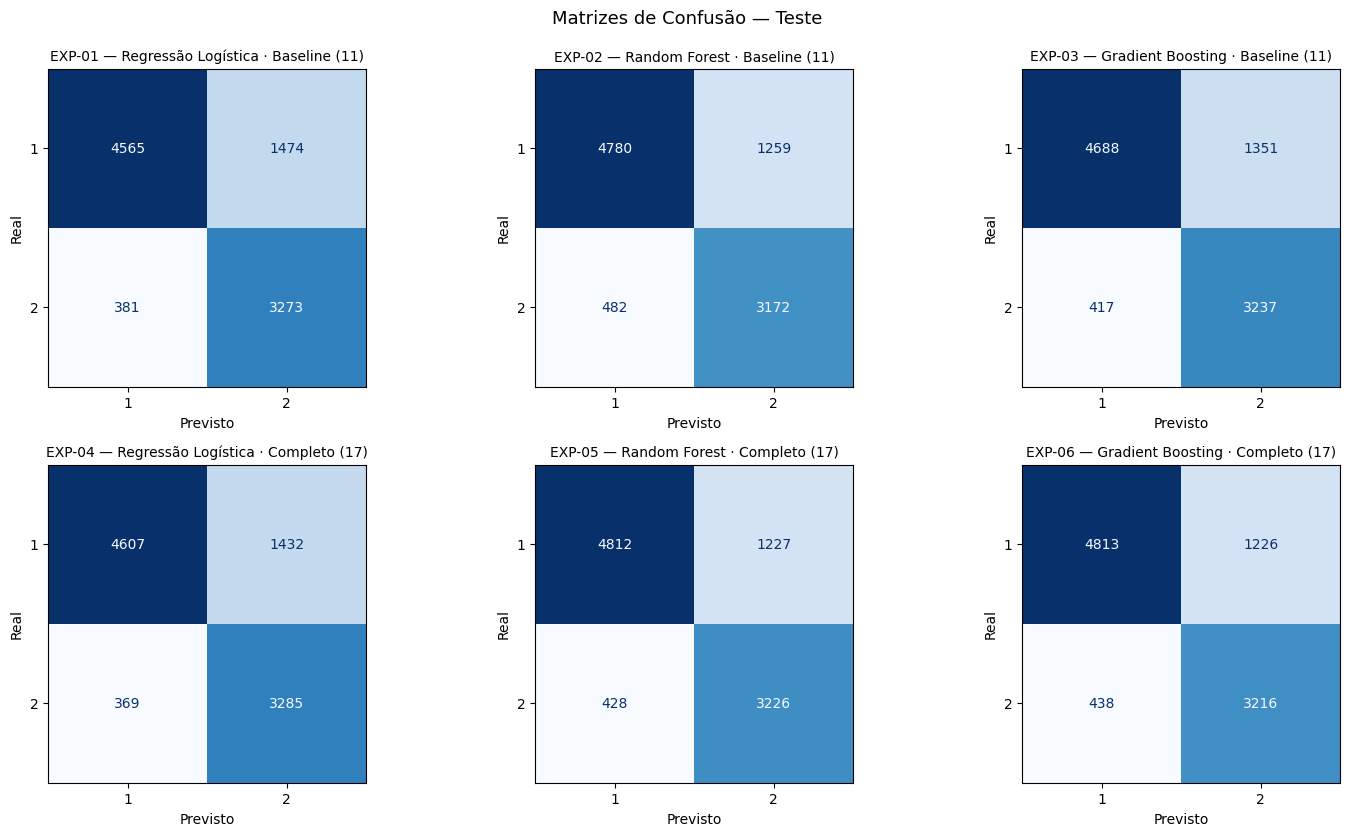

In [17]:
n = len(resultados)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.2 * nrows))
axes = axes.ravel()
for ax, reg in zip(axes, resultados):
    ConfusionMatrixDisplay(reg["_cm_teste"], display_labels=[1, 2]).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(f"{reg['exp_id']} — {reg['modelo']} · {reg['conjunto']}", fontsize=10)
    ax.set_xlabel("Previsto"); ax.set_ylabel("Real")
for ax in axes[n:]:                      # esconde eixos vazios da grade
    ax.axis("off")
fig.suptitle("Matrizes de Confusão — Teste", fontsize=13, y=0.99)
fig.tight_layout()
plt.show()

In [18]:
comp = res_df.pivot_table(index="modelo", columns="conjunto",
                          values=["teste_f1_macro", "teste_roc_auc"]).round(4)
display(comp)

melhor = res_df.sort_values(["cv_f1_macro_mean", "cv_f1_macro_std"],
                            ascending=[False, True]).iloc[0]
print("\nMelhor experimento (maior f1_macro na CV):")
print(f"  {melhor['exp_id']} — {melhor['modelo']} · {melhor['conjunto']}")
print(f"  f1_macro (CV) = {melhor['cv_f1_macro_mean']:.4f} ± {melhor['cv_f1_macro_std']:.4f}")
print(f"  f1_macro (teste) = {melhor['teste_f1_macro']:.4f} | ROC AUC (teste) = {melhor['teste_roc_auc']:.4f}")
print(f"  Hiperparâmetros: {melhor['melhores_hiperparametros']}")

teste_f1_macro               teste_roc_auc              
conjunto             Baseline (11) Completo (17) Baseline (11) Completo (17)
modelo                                                                      
Gradient Boosting           0.8134        0.8235        0.9021        0.9073
Random Forest               0.8153        0.8246        0.9032        0.9089
Regressão Logística         0.8052        0.8107        0.8948        0.8980


Melhor experimento (maior f1_macro na CV):
  EXP-06 — Gradient Boosting · Completo (17)
  f1_macro (CV) = 0.8196 ± 0.0053
  f1_macro (teste) = 0.8235 | ROC AUC (teste) = 0.9073
  Hiperparâmetros: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1}


### 9.5 Persistência de artefatos

Os pipelines treinados e as tabelas de resultados são salvos em `outputs/`. Não há um
arquivo separado de metadados de padronização: por construção, cada pipeline `.joblib`
carrega o próprio `StandardScaler` e as demais transformações.

In [19]:
for reg in resultados:
    if reg.get("_cv_results") is None:        # reaproveitado: cv_results já existe em disco
        continue
    cvr = pd.DataFrame(reg["_cv_results"])
    keep = ["params"] + [c for c in cvr.columns if c.startswith(
        ("mean_test_", "std_test_", "mean_train_", "rank_test_"))]
    ranking = cvr[keep].sort_values("rank_test_f1_macro").reset_index(drop=True)
    ranking["params"] = ranking["params"].astype(str)
    ranking.to_csv(OUTPUTS_DIR / f"cv_results_{reg['exp_id']}.csv", index=False)

colunas_resumo = ["exp_id", "conjunto", "modelo", "melhores_hiperparametros",
                  "cv_f1_macro_mean", "cv_f1_macro_std", "cv_roc_auc_mean", "cv_roc_auc_std",
                  "treino_f1_macro", "teste_accuracy", "teste_balanced_accuracy",
                  "teste_precision_pos", "teste_recall_pos", "teste_f1_pos",
                  "teste_precision_macro", "teste_recall_macro", "teste_f1_macro",
                  "teste_roc_auc"]
resumo_exp = res_df[colunas_resumo].copy()
resumo_exp["melhores_hiperparametros"] = resumo_exp["melhores_hiperparametros"].astype(str)
resumo_exp["modo_rapido"] = MODO_RAPIDO
resumo_exp.to_csv(OUTPUTS_DIR / "resumo_experimentos_arvores.csv", index=False)

for reg in resultados:
    slug = reg["modelo"].lower().replace(" ", "_")
    joblib.dump(reg["_estimator"], MODELS_DIR / f"{reg['exp_id']}_{slug}.joblib")
print("Artefatos salvos em:", OUTPUTS_DIR)

Artefatos salvos em: /home/ubuntu/datamining-project-unifei/outputs


## 10. Validação contra dados nunca vistos

Mede a **generalização** dos modelos sobre `validation/*.json`. Reusa exatamente a mesma
ingestão e transformação preguiçosas e o **mesmo imputador KNN ajustado no treino** (sem
refit) e os pipelines treinados (que já carregam o próprio scaler/TF-IDF). A coluna
`serious` da validação é só gabarito.

In [20]:
RAW_VAL_PARQUET = OUTPUTS_DIR / "_raw_reports_validation.parquet"
n_val_raw = ingest_to_parquet(sorted(VALID_DIR.glob("*.json")), RAW_VAL_PARQUET)
val_df = materialize(RAW_VAL_PARQUET)
val_df = impute_age_groups(val_df, age_imputer)  # mesmo imputador do treino, sem refit
y_val = val_df[TARGET].astype(int)

print(f"Validação: {n_val_raw} brutos -> {val_df.shape} após limpeza")
print("Distribuição de 'serious' (validação):")
print(y_val.value_counts(normalize=True).sort_index().round(4))

Validação: 24000 brutos -> (21899, 15) após limpeza
Distribuição de 'serious' (validação):
serious
1    0.5581
2    0.4419
Name: proportion, dtype: float64


In [21]:
resultados_val, cms_val = [], {}
for reg in resultados:
    cols = feature_sets["A_baseline" if "Baseline" in reg["conjunto"]
                        else "B_completo"]["colunas"]
    m = evaluate(reg["_estimator"], val_df[cols], y_val, "validacao")
    m.update(exp_id=reg["exp_id"], modelo=reg["modelo"], conjunto=reg["conjunto"],
             melhores_hiperparametros=str(reg["melhores_hiperparametros"]))
    resultados_val.append(m)
    cms_val[reg["exp_id"]] = confusion_matrix(y_val, reg["_estimator"].predict(val_df[cols]))

ordem = ["exp_id", "conjunto", "modelo", "accuracy", "balanced_accuracy",
         "precision_pos", "recall_pos", "f1_pos", "precision_macro", "recall_macro",
         "f1_macro", "roc_auc", "melhores_hiperparametros"]
val_metrics = pd.DataFrame(resultados_val)[ordem].sort_values("exp_id").reset_index(drop=True)
val_metrics.to_csv(OUTPUTS_DIR / "metricas_validacao.csv", index=False)

disp = val_metrics.copy()
for c in ordem[3:-1]:
    disp[c] = disp[c].round(4)
disp

,exp_id,conjunto,modelo,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,precision_macro,recall_macro,f1_macro,roc_auc,melhores_hiperparametros
0,EXP-01,Baseline (11),Regressão Logística,0.7778,0.7931,0.9179,0.6609,0.7685,0.8008,0.7931,0.7774,0.8555,"{'C': 10.0, 'penalty': 'l1', 'solver': 'liblin..."
1,EXP-02,Baseline (11),Random Forest,0.7772,0.7903,0.8982,0.6775,0.7724,0.7937,0.7903,0.7771,0.8613,"{'n_estimators': 200, 'min_samples_split': 5, ..."
2,EXP-03,Baseline (11),Gradient Boosting,0.7730,0.7871,0.9018,0.6658,0.7660,0.7923,0.7871,0.7728,0.8612,"{'n_estimators': 200, 'max_depth': 5, 'learnin..."
3,EXP-04,Completo (17),Regressão Logística,0.7810,0.7968,0.9251,0.6611,0.7711,0.8052,0.7968,0.7806,0.8636,"{'C': 1.0, 'penalty': 'l1', 'solver': 'libline..."
4,EXP-05,Completo (17),Random Forest,0.7829,0.7967,0.9105,0.6775,0.7769,0.8014,0.7967,0.7827,0.8665,"{'n_estimators': 300, 'min_samples_split': 2, ..."
5,EXP-06,Completo (17),Gradient Boosting,0.7822,0.7955,0.9053,0.6810,0.7773,0.7992,0.7955,0.7821,0.8693,"{'n_estimators': 300, 'max_depth': 7, 'learnin..."


In [22]:
# Comparação teste × validação: quedas pequenas indicam boa generalização.
resumo_idx = res_df.set_index("exp_id")
comp_rows = []
for r in resultados_val:
    eid = r["exp_id"]
    comp_rows.append({
        "exp_id": eid, "modelo": r["modelo"], "conjunto": r["conjunto"],
        "teste_f1_macro": resumo_idx.loc[eid, "teste_f1_macro"],
        "validacao_f1_macro": r["f1_macro"],
        "delta_f1_macro": r["f1_macro"] - resumo_idx.loc[eid, "teste_f1_macro"],
        "teste_roc_auc": resumo_idx.loc[eid, "teste_roc_auc"],
        "validacao_roc_auc": r["roc_auc"],
        "delta_roc_auc": r["roc_auc"] - resumo_idx.loc[eid, "teste_roc_auc"],
    })
comp_df = pd.DataFrame(comp_rows).round(4)
comp_df.to_csv(OUTPUTS_DIR / "comparacao_teste_validacao.csv", index=False)
comp_df

,exp_id,modelo,conjunto,teste_f1_macro,validacao_f1_macro,delta_f1_macro,teste_roc_auc,validacao_roc_auc,delta_roc_auc
0,EXP-01,Regressão Logística,Baseline (11),0.8052,0.7774,-0.0278,0.8948,0.8555,-0.0393
1,EXP-02,Random Forest,Baseline (11),0.8153,0.7771,-0.0382,0.9032,0.8613,-0.0419
2,EXP-03,Gradient Boosting,Baseline (11),0.8134,0.7728,-0.0406,0.9021,0.8612,-0.0409
3,EXP-04,Regressão Logística,Completo (17),0.8107,0.7806,-0.0301,0.8980,0.8636,-0.0344
4,EXP-05,Random Forest,Completo (17),0.8246,0.7827,-0.0418,0.9089,0.8665,-0.0424
5,EXP-06,Gradient Boosting,Completo (17),0.8235,0.7821,-0.0415,0.9073,0.8693,-0.0380


## 11. Conclusões

- **Execução preguiçosa de ponta a ponta:** Polars LazyFrame (uma `collect` em
  *streaming*) combinado a um pipeline sklearn/imblearn que só executa no `.fit()`. A
  única materialização intermediária é o imputador KNN supervisionado da faixa etária.
- **Balanceamento por SMOTE:** equilibra `serious` automaticamente (qualquer proporção) e
  apenas nos *folds* de treino, sem vazamento.
- **DoE completo:** Regressão Logística, Random Forest e Gradient Boosting × Baseline /
  Completo (EXP-01 a EXP-06), avaliados no teste e validados contra dados nunca vistos.
- Artefatos persistidos em `outputs/` (modelos `.joblib`, resumos e comparação
  teste × validação).